In [1]:
import logging

import numpy as np
import matplotlib.pyplot as plt

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s %(levelname)s %(name)-40s :: %(message)s'
)


# Inverse Obstacle problem 

Operator that maps the shape of a sound-soft obstacle to the far-field measurements. 
The scattering problem is described by

$$
        \begin{cases}
            \Delta u +\kappa^2 u = 0 & \text{ in } \mathbb{R}^2\backslash\overline{D}\\
             u = 0  & \text{ on } \partial D\\
            \displaystyle{\lim_{r\to\infty}}r^{\frac{1}{2}}(\frac{\partial u^s}{\partial r}-i\kappa u^s)=0 & \text{ for } r=|x|,
        \end{cases}
$$
where $u=u^s+u^i$ is the total field and $D$ is a bounded obstacle in $\mathbb{R}^2$ with $\partial D\in\mathcal{C}^2$.
    

In [2]:
from  dirichlet_op import DirichletOp

#Forward operator
op = DirichletOp(
    kappa = 3,
    N_inc=4
)


In [3]:
from regpy.solvers import RegularizationSetting
from regpy.hilbert import L2, Sobolev
from dirichlet_op import create_synthetic_data

setting = RegularizationSetting(op=op, penalty=Sobolev, data_fid=L2)

#Exact data
farfield, exact_solution = create_synthetic_data(op, true_curve='apple')

# Gaussian data 
noise_level = 0.01
noise = op.codomain.randn()
noise = noise_level*setting.h_codomain.norm(farfield)/setting.h_codomain.norm(noise)*noise
data = farfield+noise

#Initial guess
t = 2*np.pi*np.arange(0, op.N_FK)/op.N_FK
init = 0.45*np.append(np.cos(t), np.sin(t)).reshape((2, op.N_FK))
init=init.flatten()

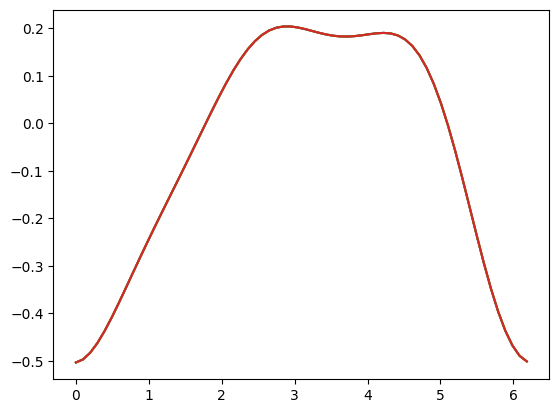

In [4]:
x= op.codomain.coords[0]
y = farfield[:,0]
plt.plot(x,np.real(y))


2024-04-30 19:19:06,903 INFO CountIterations                          :: iteration = 1 / 100
2024-04-30 19:19:06,904 INFO Discrepancy                              :: relative discrepancy = 66.57, tolerance = 2.10
2024-04-30 19:19:08,896 INFO NewtonCG                                 :: Inner CG iteration required 1 steps.
2024-04-30 19:19:10,022 INFO CountIterations                          :: iteration = 2 / 100
2024-04-30 19:19:10,023 INFO Discrepancy                              :: relative discrepancy = 24.06, tolerance = 2.10
2024-04-30 19:19:12,328 INFO NewtonCG                                 :: Inner CG iteration required 1 steps.
2024-04-30 19:19:12,799 INFO CountIterations                          :: iteration = 3 / 100
2024-04-30 19:19:12,800 INFO Discrepancy                              :: relative discrepancy = 10.96, tolerance = 2.10
2024-04-30 19:19:16,428 INFO NewtonCG                                 :: Inner CG iteration required 3 steps.
2024-04-30 19:19:17,233 INFO Co

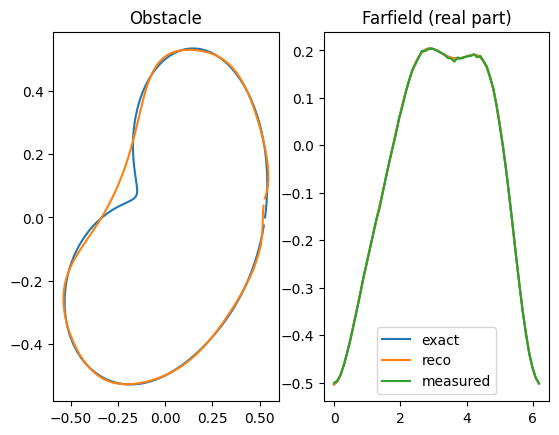

In [5]:
from regpy.solvers.nonlinear.irgnm import IrgnmCG
from regpy.solvers.nonlinear.newton import NewtonCG
import regpy.stoprules as rules

#Solver: NewtonCG or IrgnmCG
solver = NewtonCG(
    setting, data, init = init,
        cgmaxit=50, rho=0.6
)

"""
solver = IrgnmCG(
    setting, data,
    regpar=1.,
    regpar_step=0.5,
    init=init
)
"""
stoprule = (
    rules.CountIterations(100) +
    rules.Discrepancy(
        setting.h_codomain.norm, data,
        noiselevel=noise_level,
        tau=2.1
    )
)

#Plot function
fig, axs = plt.subplots(1, 2)
axs[0].set_title('Obstacle')
axs[1].set_title('Farfield (real part)')

reco, reco_data = solver.run(stoprule)
axs[0].plot(*exact_solution.z)
axs[0].plot(*op.domain.bd_eval(reco, nvals=op.N_ieq, nderivs=3).z)

axs[1].plot(op.codomain.coords[0][:,0], farfield.real[:,0], label='exact')
axs[1].plot(op.codomain.coords[0][:,0], reco_data.real[:,0], label='reco')
axs[1].plot(op.codomain.coords[0][:,0], data.real[:,0], label='measured')
axs[1].legend()
plt.show()